# GARCH Testing Notebook
This notebook exercises the GARCH utilities in `pairs_trading.models.garch` using a sample returns series.

## 1) Load Libraries and Local Modules

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pairs_trading.data.fetcher import fetch_price_data
from pairs_trading.data.schemas import Asset
from pairs_trading.models.garch import (
    GarchSpec,
    fit_garch,
    forecast_volatility,
    validate_returns,
)

## 2) Load or Simulate Returns Series

In [ ]:
# Option A: Fetch price data with yfinance via fetcher.py
asset = Asset(symbol="AAPL")
start = pd.Timestamp("2020-01-01")
end = pd.Timestamp("2024-01-01")

price_data = fetch_price_data(asset, start, end)
prices = price_data.close

# Compute log returns
returns = np.log(prices).diff().dropna()
returns.name = "returns"

# Option B: Simulate returns (self-contained)
# np.random.seed(42)
# n = 1000
# dates = pd.date_range("2020-01-01", periods=n, freq="B")
# returns = pd.Series(np.random.normal(0, 0.01, size=n), index=dates, name="returns")

# Option C: Load from CSV (expects a 'returns' column)
# returns = pd.read_csv("./data/returns.csv", parse_dates=["date"], index_col="date")["returns"]

returns.head()

2020-01-01    0.004967
2020-01-02   -0.001383
2020-01-03    0.006477
2020-01-06    0.015230
2020-01-07   -0.002342
Freq: B, Name: returns, dtype: float64

## 3) Validate Returns and Explore Basic Stats

In [3]:
clean_returns = validate_returns(returns)

clean_returns.describe()

count    1000.000000
mean        0.000193
std         0.009792
min        -0.032413
25%        -0.006476
50%         0.000253
75%         0.006479
max         0.038527
Name: returns, dtype: float64

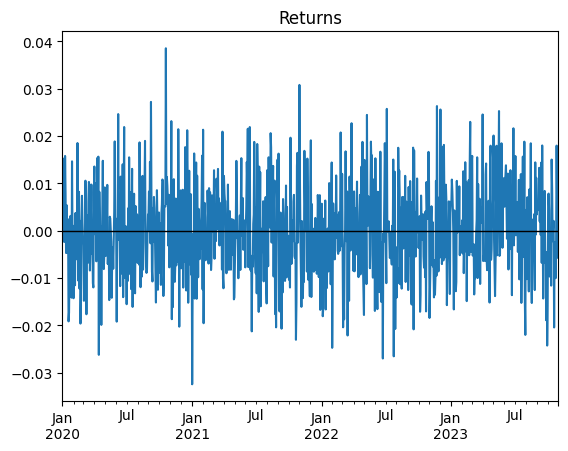

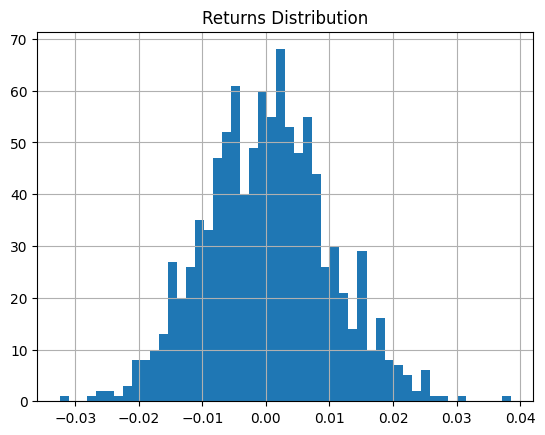

In [4]:
ax = clean_returns.plot(title="Returns")
ax.axhline(0, color="black", linewidth=1)
plt.show()

clean_returns.hist(bins=50)
plt.title("Returns Distribution")
plt.show()

## 4) Fit Baseline GARCH Model

In [5]:
baseline_spec = GarchSpec(p=1, q=1, mean="Zero", dist="t")
result = fit_garch(clean_returns, baseline_spec)

result.params

omega       1.354503e-02
alpha[1]    4.106135e-08
beta[1]     9.860276e-01
nu          1.163042e+02
Name: params, dtype: float64

## 5) Inspect Parameters and Diagnostics

In [6]:
result.params

result.residuals.head()

result.volatility.tail()

print(result.model_summary[:1000])

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                      returns   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:               -1397.26
Distribution:      Standardized Student's t   AIC:                           2802.53
Method:                  Maximum Likelihood   BIC:                           2822.16
                                              No. Observations:                 1000
Date:                      Sat, Jan 31 2026   Df Residuals:                     1000
Time:                              14:56:10   Df Model:                            0
                               Volatility Model                              


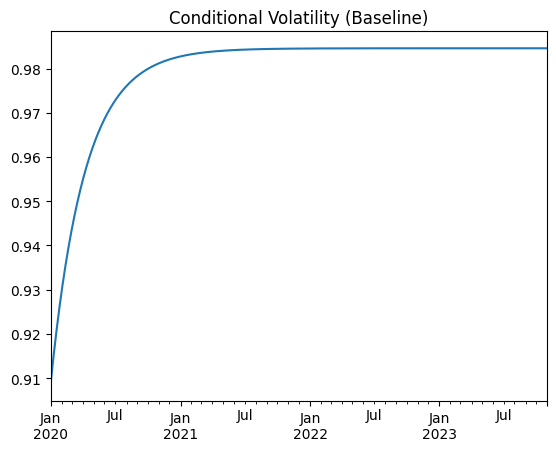

In [7]:
result.volatility.plot(title="Conditional Volatility (Baseline)")
plt.show()

## 6) Compare Alternative Specifications

In [8]:
specs = {
    "Zero_t": GarchSpec(mean="Zero", dist="t"),
    "Constant_normal": GarchSpec(mean="Constant", dist="normal"),
    "Zero_ged": GarchSpec(mean="Zero", dist="ged"),
}

rows = []
for name, spec in specs.items():
    res = fit_garch(clean_returns, spec)
    rows.append(
        {
            "spec": name,
            "vol_mean": float(res.volatility.mean()),
            "resid_var": float(res.residuals.var()),
        }
    )

pd.DataFrame(rows).sort_values("vol_mean")

,spec,vol_mean,resid_var
1,Constant_normal,0.978798,0.958864
0,Zero_t,0.979258,0.958864
2,Zero_ged,0.979425,0.958864


## 7) Forecast Volatility and Plot Results

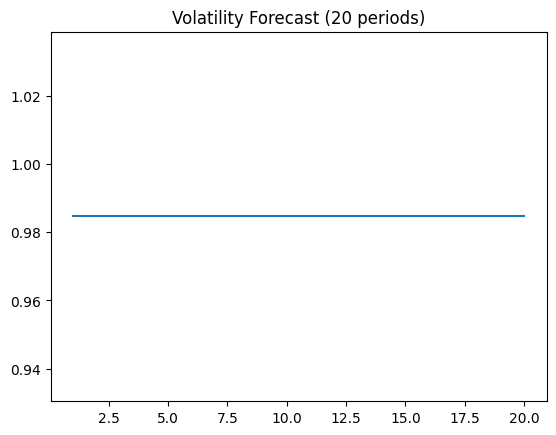

In [9]:
forecast = forecast_volatility(result, horizon=20)

forecast.plot(title="Volatility Forecast (20 periods)")
plt.show()

## 8) Persist Results to Disk

In [10]:
from pathlib import Path

output_dir = Path("./notebooks/output")
output_dir.mkdir(parents=True, exist_ok=True)

# Save params and volatility
result.params.to_csv(output_dir / "garch_params.csv")
result.volatility.to_csv(output_dir / "garch_volatility.csv")
forecast.to_csv(output_dir / "garch_forecast.csv")

# Save plots
ax = result.volatility.plot(title="Conditional Volatility (Baseline)")
fig = ax.get_figure()
fig.savefig(output_dir / "garch_volatility.png", bbox_inches="tight")
plt.close(fig)

ax = forecast.plot(title="Volatility Forecast (20 periods)")
fig = ax.get_figure()
fig.savefig(output_dir / "garch_forecast.png", bbox_inches="tight")
plt.close(fig)

output_dir

PosixPath('notebooks/output')